# Дополнительные гипотезы H10–H12 и история сущностей

После отбора основной модели проверяем новые поведенческие блоки и строго прошлую историю сущностей. Все исторические признаки строятся заново внутри каждого временного разбиения.

## Проверяемые варианты

| Гипотеза | Набор | Что проверяем |
|---|---|---|
| H10 | `behavior_with_entity_history` | История объявлений, запросов, User-Agent, категории × региона и User-Agent × категории |
| H11 | `behavior_with_non_item_history` | Контроль без объявлений и переносимость на куки с новыми объявлениями |
| H12 | `behavior_with_item_history` | Упрощённый вариант только с историей объявлений |

Сравнение второго и первого вариантов показывает вклад объявлений. Третий вариант проверяет, можно ли удалить остальные исторические признаки без потери качества.

In [1]:
import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from artifacts import config_hash, configure_logging
from config import ARTIFACT_DIR, CATBOOST_FINAL_PARAMS, REPORT_DIR, TIME_FOLDS, ExperimentConfig
from data import load_metadata, load_or_prepare_events
from experiments import run_time_cv
from feature_sets import FEATURE_SET_SPECS, build_feature_set
from metric import precision_at_recall

configure_logging()
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
TABLE_DIR = REPORT_DIR / "tables"
FIGURE_DIR = REPORT_DIR / "figures" / "experiments"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\Kolya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Подготовка данных

Локальные блоки считаются один раз и сохраняются отдельно. При повторном запуске они загружаются из кеша.

In [2]:
data = load_metadata()
events = load_or_prepare_events(data.metadata)
rich_behavior, _ = build_feature_set(
    "rich_behavior",
    data.metadata,
    data.train,
    events,
)
pd.Series({
    "rows": len(rich_behavior),
    "local_features": rich_behavior.shape[1] - 1,
}).to_frame("value")

15:46:15 | INFO | data | Метаданные загружены: train=11091, test=4909, ботов=899
15:46:16 | INFO | artifacts | События внутри окон: кеш, строк=288126, колонок=18
15:46:16 | INFO | feature_sets | Поведенческие наборы загружены из кеша
15:46:16 | INFO | artifacts | Блок признаков sequence: кеш, строк=16000, колонок=271
15:46:16 | INFO | artifacts | Блок признаков pointer_dynamics: кеш, строк=16000, колонок=82
15:46:16 | INFO | artifacts | Блок признаков missingness: кеш, строк=16000, колонок=97
15:46:16 | INFO | artifacts | Блок признаков text_hash: кеш, строк=16000, колонок=199


,value
rows,16000
local_features,705


## План экспериментов H10–H12

Используем параметры CatBoost, выбранные до проверки исторических гипотез. Для свежих строк train применяются веса с периодом полураспада пять дней.

In [3]:
HISTORY_FEATURE_SETS = [
    "behavior_with_entity_history",
    "behavior_with_non_item_history",
    "behavior_with_item_history",
]
history_plan = pd.DataFrame([
    {
        "feature_set": name,
        "history_entities": FEATURE_SET_SPECS[name].history_entities,
        "history_alpha": FEATURE_SET_SPECS[name].history_alpha,
        "recency_half_life_days": FEATURE_SET_SPECS[name].recency_half_life_days,
    }
    for name in HISTORY_FEATURE_SETS
])
history_plan

,feature_set,history_entities,history_alpha,recency_half_life_days
0,behavior_with_entity_history,"(item, query, user_agent, category_location, u...",25.0,5.0
1,behavior_with_non_item_history,"(query, user_agent, category_location, ua_cate...",25.0,5.0
2,behavior_with_item_history,"(item,)",25.0,5.0


## Обучение CatBoost

In [4]:
EXPECTED_FEATURE_COUNTS = {
    "behavior_with_entity_history": 751,
    "behavior_with_non_item_history": 743,
    "behavior_with_item_history": 719,
}
history_results = []
history_configs = {}
for feature_set_name in HISTORY_FEATURE_SETS:
    spec = FEATURE_SET_SPECS[feature_set_name]
    config = ExperimentConfig(
        name=f"catboost_{feature_set_name}",
        feature_set=feature_set_name,
        model_name="catboost",
        model_params=CATBOOST_FINAL_PARAMS,
        frequency_feature_style="prefix",
        history_entities=spec.history_entities,
        history_alpha=spec.history_alpha,
        recency_half_life_days=spec.recency_half_life_days,
        expected_feature_count=EXPECTED_FEATURE_COUNTS[feature_set_name],
        feature_version="compact_behavior_v1_with_local_blocks_v1",
        compute_mode="cpu",
    )
    history_configs[feature_set_name] = config
    result = run_time_cv(
        config,
        rich_behavior,
        data.train,
        events=events,
    )
    history_results.append(result)

history_results = pd.DataFrame(history_results).sort_values(
    ["mean_precision_at_recall_70", "last_fold_precision_at_recall_70"],
    ascending=False,
).reset_index(drop=True)
history_results.to_csv(TABLE_DIR / "history_experiments.csv", index=False)
history_results

15:46:17 | INFO | experiments | catboost_behavior_with_entity_history: модель=catboost, набор=behavior_with_entity_history, признаков до истории=705
15:46:17 | INFO | validation | fold_01: train=5930, valid=1669, valid_bots=123
15:46:17 | INFO | history_features | Исторические признаки: train=5930, valid=1669, alpha=25.0
История сущностей: 100%|██████████| 5/5 [00:34<00:00,  6.86s/тип]
15:46:51 | INFO | history_features | Исторические признаки готовы: типов=5, колонок=40


0:	test: 0.8489703	best: 0.8489703 (0)	total: 187ms	remaining: 3m 44s
100:	test: 0.9315096	best: 0.9316358 (98)	total: 6.14s	remaining: 1m 6s
200:	test: 0.9367684	best: 0.9367736 (199)	total: 11.7s	remaining: 58.1s
300:	test: 0.9405547	best: 0.9411279 (293)	total: 17.1s	remaining: 51s
400:	test: 0.9451877	best: 0.9454191 (392)	total: 23.1s	remaining: 46.1s
500:	test: 0.9466759	best: 0.9466759 (499)	total: 29.5s	remaining: 41.2s
600:	test: 0.9471492	best: 0.9471492 (600)	total: 34.4s	remaining: 34.3s
700:	test: 0.9470230	best: 0.9471702 (603)	total: 39.8s	remaining: 28.4s
800:	test: 0.9464551	best: 0.9471702 (603)	total: 44.5s	remaining: 22.2s
900:	test: 0.9460291	best: 0.9471702 (603)	total: 49.1s	remaining: 16.3s
1000:	test: 0.9455400	best: 0.9471702 (603)	total: 53.4s	remaining: 10.6s
1100:	test: 0.9467864	best: 0.9471702 (603)	total: 58.2s	remaining: 5.23s
1199:	test: 0.9462710	best: 0.9471702 (603)	total: 1m 2s	remaining: 0us

bestTest = 0.9471702479
bestIteration = 603



15:47:56 | INFO | experiments | catboost_behavior_with_entity_history | fold_01 | P@R70=0.7909 | AP=0.8039 | ROC-AUC=0.9463 | 64.3 с
15:47:56 | INFO | validation | fold_02: train=7599, valid=1541, valid_bots=125
15:47:56 | INFO | history_features | Исторические признаки: train=7599, valid=1541, alpha=25.0
История сущностей: 100%|██████████| 5/5 [00:50<00:00, 10.12s/тип]
15:48:47 | INFO | history_features | Исторические признаки готовы: типов=5, колонок=40


0:	test: 0.7811441	best: 0.7811441 (0)	total: 45.3ms	remaining: 54.3s
100:	test: 0.9375989	best: 0.9377684 (95)	total: 5.47s	remaining: 59.5s
200:	test: 0.9426893	best: 0.9428136 (196)	total: 11.5s	remaining: 57.4s
300:	test: 0.9425198	best: 0.9439718 (258)	total: 16.3s	remaining: 48.8s
400:	test: 0.9423842	best: 0.9439718 (258)	total: 20.9s	remaining: 41.6s
500:	test: 0.9436102	best: 0.9439718 (258)	total: 25.2s	remaining: 35.2s
600:	test: 0.9441469	best: 0.9442429 (596)	total: 29.3s	remaining: 29.2s
700:	test: 0.9447966	best: 0.9452147 (636)	total: 33.3s	remaining: 23.7s
800:	test: 0.9448814	best: 0.9453107 (759)	total: 37.3s	remaining: 18.6s
900:	test: 0.9452260	best: 0.9454294 (822)	total: 41.4s	remaining: 13.7s
1000:	test: 0.9446780	best: 0.9458475 (938)	total: 45.4s	remaining: 9.02s
1100:	test: 0.9442768	best: 0.9458475 (938)	total: 49.4s	remaining: 4.44s


15:49:44 | INFO | experiments | catboost_behavior_with_entity_history | fold_02 | P@R70=0.9000 | AP=0.8159 | ROC-AUC=0.9441 | 55.9 с


...

15:58:10 | INFO | history_features | Исторические признаки: train=9140, valid=1951, alpha=25.0
История сущностей: 100%|██████████| 1/1 [00:05<00:00,  5.13s/тип]
15:58:16 | INFO | history_features | Исторические признаки готовы: типов=1, колонок=8


0:	test: 0.8100415	best: 0.8100415 (0)	total: 30.2ms	remaining: 36.2s
100:	test: 0.9308417	best: 0.9308417 (100)	total: 4.63s	remaining: 50.4s
200:	test: 0.9376012	best: 0.9376012 (200)	total: 8.77s	remaining: 43.6s
300:	test: 0.9410699	best: 0.9410699 (300)	total: 16.2s	remaining: 48.3s
400:	test: 0.9421901	best: 0.9426542 (353)	total: 21.3s	remaining: 42.4s
500:	test: 0.9431219	best: 0.9432789 (461)	total: 25.7s	remaining: 35.9s
600:	test: 0.9426577	best: 0.9433696 (511)	total: 31s	remaining: 30.9s
700:	test: 0.9422634	best: 0.9433696 (511)	total: 35.5s	remaining: 25.3s
800:	test: 0.9423960	best: 0.9433696 (511)	total: 39.9s	remaining: 19.9s
900:	test: 0.9419214	best: 0.9433696 (511)	total: 44.2s	remaining: 14.7s
1000:	test: 0.9415829	best: 0.9433696 (511)	total: 48.4s	remaining: 9.63s
1100:	test: 0.9417155	best: 0.9433696 (511)	total: 52.6s	remaining: 4.73s


15:59:15 | INFO | experiments | catboost_behavior_with_item_history | fold_03 | P@R70=0.8507 | AP=0.8006 | ROC-AUC=0.9414 | 58.6 с
15:59:15 | INFO | experiments | catboost_behavior_with_item_history завершён: mean P@R70=0.8687, last=0.8507


1199:	test: 0.9414119	best: 0.9433696 (511)	total: 57.4s	remaining: 0us

bestTest = 0.9433696259
bestIteration = 511



,experiment,feature_set,model,feature_count,total_fit_seconds,mean_precision_at_recall_70,std_precision_at_recall_70,last_fold_precision_at_recall_70,mean_average_precision,mean_roc_auc,pooled_precision_at_recall_70,pooled_average_precision,pooled_roc_auc
0,catboost_behavior_with_item_history,behavior_with_item_history,catboost,719,174.065347,0.868664,0.028648,0.850746,0.808896,0.944549,0.855882,0.805092,0.944329
1,catboost_behavior_with_entity_history,behavior_with_entity_history,catboost,751,187.217107,0.844338,0.044564,0.842105,0.805929,0.944556,0.853731,0.800331,0.943914
2,catboost_behavior_with_non_item_history,behavior_with_non_item_history,catboost,743,179.395456,0.665089,0.080111,0.767123,0.751014,0.929415,0.652273,0.750011,0.928862


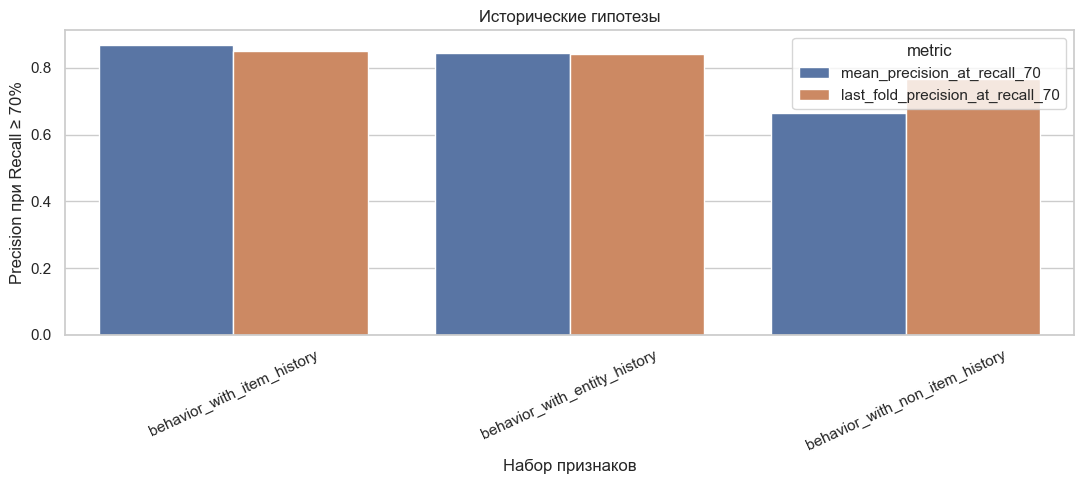

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_table = history_results.melt(
    id_vars="feature_set",
    value_vars=["mean_precision_at_recall_70", "last_fold_precision_at_recall_70"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=plot_table, x="feature_set", y="value", hue="metric", ax=ax)
ax.set_title("Исторические гипотезы")
ax.set_xlabel("Набор признаков")
ax.set_ylabel("Precision при Recall ≥ 70%")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "history_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## H11: проверка знакомых и новых объявлений

Для варианта только с историей объявлений отдельно смотрим долю кук со знакомыми объявлениями и качество на таких куках. Это диагностическая проверка переносимости, а не дополнительный подбор модели.

In [6]:
item_config = history_configs["behavior_with_item_history"]
item_run_hash = config_hash(asdict(item_config))
item_run_dir = ARTIFACT_DIR / "experiments" / item_config.name / item_run_hash
coverage_rows = []
for fold in TIME_FOLDS:
    predictions = pd.read_csv(item_run_dir / fold.name / "valid_predictions.csv")
    history = pd.read_pickle(item_run_dir / fold.name / "history" / "valid.pkl")
    audit = predictions.merge(
        history[["cookie_id", "item_history_seen_share"]],
        on="cookie_id",
        validate="one_to_one",
    )
    audit["known_item"] = audit["item_history_seen_share"] > 0
    for known_item, part in audit.groupby("known_item"):
        metric = float("nan")
        if part["target"].nunique() == 2:
            metric = precision_at_recall(part["target"], part["score"])
        coverage_rows.append({
            "fold": fold.name,
            "group": "known_item" if known_item else "new_item",
            "rows": len(part),
            "row_share": len(part) / len(audit),
            "bots": int(part["target"].sum()),
            "bot_share_inside_fold": part["target"].sum() / audit["target"].sum(),
            "precision_at_recall_70": metric,
        })
coverage_audit = pd.DataFrame(coverage_rows)
coverage_audit.to_csv(TABLE_DIR / "item_history_coverage.csv", index=False)
coverage_audit

,fold,group,rows,row_share,bots,bot_share_inside_fold,precision_at_recall_70
0,fold_01,new_item,101,0.060515,0,0.00000,NaN
1,fold_01,known_item,1568,0.939485,123,1.00000,0.846154
2,fold_02,new_item,88,0.057106,1,0.00800,1.000000
3,fold_02,known_item,1453,0.942894,124,0.99200,0.909091
4,fold_03,new_item,75,0.038442,1,0.00625,1.000000
5,fold_03,known_item,1876,0.961558,159,0.99375,0.849624


## Покрытие test знакомыми объявлениями

Используем только значения признаков test, без разметки. Эта таблица не участвует в выборе параметров.

In [7]:
train_cookie_ids = set(data.train["cookie_id"])
test_cookie_ids = set(data.test["cookie_id"])
known_items = set(
    events.loc[events["cookie_id"].isin(train_cookie_ids), "item_id"].dropna()
)
test_pairs = events.loc[
    events["cookie_id"].isin(test_cookie_ids),
    ["cookie_id", "item_id"],
].dropna().drop_duplicates()
test_pairs["known_item"] = test_pairs["item_id"].isin(known_items)
test_coverage = data.test[["cookie_id"]].merge(
    test_pairs.groupby("cookie_id")["known_item"].agg(["any", "mean", "count"]).reset_index(),
    on="cookie_id",
    how="left",
)
test_coverage[["any", "mean", "count"]] = test_coverage[["any", "mean", "count"]].fillna(0)
pd.Series({
    "cookies_with_known_item_share": test_coverage["any"].astype(bool).mean(),
    "mean_known_item_share": test_coverage["mean"].mean(),
    "cookies_without_item_events": int(test_coverage["count"].eq(0).sum()),
}).to_frame("value")

,value
cookies_with_known_item_share,0.971685
mean_known_item_share,0.807235
cookies_without_item_events,65.000000


## Выводы после запуска

1. Лучшим оказался вариант только с историей объявлений: средняя Precision при Recall не ниже 70% равна 0,8687, значения по периодам — 0,8462, 0,9091 и 0,8507. Объединённая оценка по всем проверочным строкам равна 0,8559.
2. История сразу пяти типов сущностей дала 0,8443. Она полезна, но немного уступает более простому варианту из 719 признаков. Истории запросов, клиента и сочетаний категорий добавляют сложность и шум.
3. Контрольный вариант без объявлений дал только 0,6651. Значит, основной прирост обеспечивает именно повторяемость объявлений и статистика прошлых взаимодействий с ними, а не произвольное запоминание строк клиента или запросов.
4. В проверочных периодах от 93,9% до 96,2% кук имеют знакомые объявления. На них метрика составляет 0,8462, 0,9091 и 0,8496. В группах с новыми объявлениями всего ноль или один бот, поэтому отдельная метрика для них статистически неустойчива и не используется для выбора модели.
5. В test у 97,17% кук встречается хотя бы одно объявление из train, а средняя доля известных объявлений равна 80,72%. Для 65 кук событий с объявлениями нет; для них остаются локальные поведенческие признаки и сглаженные исторические значения.
6. `item_id` не передаётся CatBoost как категориальный или числовой признак. По идентификатору до начала текущего окна считаются только сглаженные агрегаты прошлой разметки. Внутри каждого временного разбиения они строятся заново, поэтому разметка проверочного периода и будущее не используются.
7. Для финального решения выбираем набор `behavior_with_item_history`: он одновременно лучше по основной метрике, проще полного исторического варианта и устойчив на последнем временном периоде.